<a href="https://colab.research.google.com/github/JayV1I/Aulas-pucc/blob/main/trabalho_Explorando_Vi%C3%A9s_Vari%C3%A2ncia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TRABALHO 1:

Joao Vitor RA: 23007781




##import

##treino

In [23]:
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import Dense

In [24]:
def f1(x):
    return 0.5*x + 0.3 + np.random.uniform(-0.1, 0.1, size=x.shape)

In [25]:
def f2(x):
    return 0.5*x**2 - 0.3*x + 0.8 + np.random.uniform(-0.1, 0.1, size=x.shape)


In [26]:
def gerar_dataset(n, func):
    x = np.random.uniform(0, 1, n)
    y = func(x)
    return x.reshape(-1,1), y.reshape(-1,1)


size = [2,5,10,20,30,40,50,100,150,200,300,400,500]

##modelo:

In [27]:
def modelo_A():
    model = Sequential([
        Dense(1, input_dim=1, activation='linear')
    ])
    model.compile(optimizer='sgd', loss='mse')
    return model

In [28]:
def modelo_B():
    model = Sequential([
        Dense(2, input_dim=1, activation='linear'),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='sgd', loss='mse')
    return model

In [29]:
def modelo_C():
    model = Sequential([
        Dense(30, input_dim=1, activation='linear'),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='sgd', loss='mse')
    return model



In [30]:
# backup dos modelos
base_A = modelo_A()
base_B = modelo_B()
base_C = modelo_C()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##metricas:

In [31]:
def avaliar(model, x, y):
    pred = model.predict(x, verbose=0)
    mae = mean_absolute_error(y, pred)
    mse = mean_squared_error(y, pred)
    rmse = np.sqrt(mse)
    return mae, mse, rmse

In [36]:
#loop experimento
resultados = []

for func, nome_func in [(f1, "f1"), (f2, "f2")]:

    for s in size:
        x_train, y_train = gerar_dataset(s, func)
        x_test, y_test = gerar_dataset(1000, func)

        for base_model, nome_modelo in [
            (base_A, "A"),
            (base_B, "B"),
            (base_C, "C")
        ]:
            # copia do modelo (mantém pesos iniciais)
            model = clone_model(base_model)
            model.set_weights(base_model.get_weights())
            model.compile(optimizer='sgd', loss='mse')

            # treino
            history = model.fit(x_train, y_train, epochs=200, verbose=0)
            loss_treino = history.history['loss'][-1]

            # avaliação
            mae, mse, rmse = avaliar(model, x_test, y_test)

            resultados.append({
                "func": nome_func,
                "modelo": nome_modelo,
                "size": s,
                "loss_treino": loss_treino,
                "mae": mae,
                "mse": mse,
                "rmse": rmse
            })


In [37]:
df_resultados = pd.DataFrame(resultados)
display(df_resultados.head())

,func,modelo,size,loss_treino,mae,mse,rmse
0,f1,A,2,0.001935,0.108160,0.017414,0.131960
1,f1,B,2,0.001952,0.112940,0.018930,0.137586
2,f1,C,2,0.001971,0.117558,0.020449,0.143000
3,f1,A,5,0.015651,0.128191,0.023659,0.153815
4,f1,B,5,0.005467,0.074302,0.008251,0.090835


In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_resultados, x='size', y='mae', hue='modelo', style='func', marker='o')
plt.title('MAE vs. Dataset Size for Different Models and Functions')
plt.xlabel('Dataset Size')
plt.ylabel('Mean Absolute Error (MAE)')
plt.xscale('log') # Use a log scale for dataset size if it spans a wide range
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend(title='Model/Function')
plt.tight_layout()
plt.show()

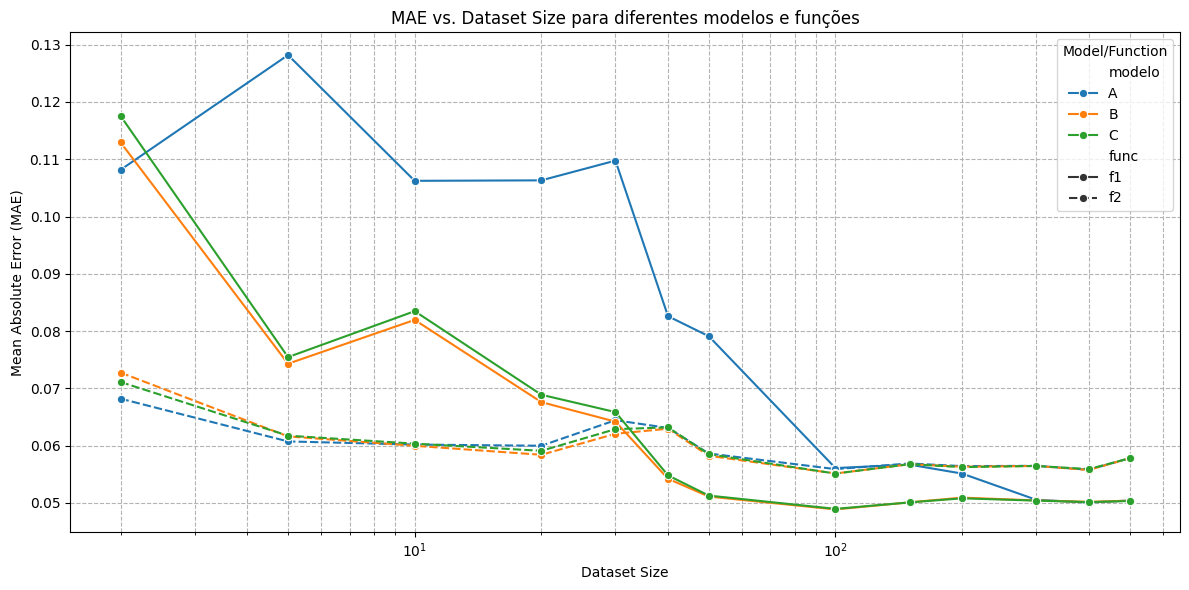

In [38]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_resultados, x='size', y='mae', hue='modelo', style='func', marker='o')
plt.title('MAE vs. Dataset Size para diferentes modelos e funções')
plt.xlabel('Dataset Size')
plt.ylabel('Mean Absolute Error (MAE)')
plt.xscale('log')
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend(title='Model/Function')
plt.tight_layout()
plt.show()